#### Step 1

In [2]:
import pandas as pd
import numpy as np

df = pd.read_stata("1.5kcolleges_student&collegedetails_v2_limitedvars.dta")

# Work on a clean copy
df_feat = df.copy()

# Ensure consistent types
df_feat["marks"] = pd.to_numeric(df_feat["marks"], errors="coerce")

df_feat["allotted_JC_code"] = (
    df_feat["allotted_JC_code"]
    .astype(str)
    .str.strip()
    .str.lower()
)


In [13]:
# -----------------------------
# FILTER: Residential colleges only
# -----------------------------

# ensure clean string
df_feat["allotted_JC_code"] = (
    df_feat["allotted_JC_code"]
    .astype(str)
    .str.strip()
)

# keep only students with a valid allotted college
df_feat = df_feat[df_feat["allotted_JC_code"].notna()]
df_feat = df_feat[df_feat["allotted_JC_code"] != ""]
df_feat = df_feat[~df_feat["allotted_JC_code"].isin(["nan", "None"])]

print("After residential-college filter:")
print("Students remaining:", df_feat.shape[0])


After residential-college filter:
Students remaining: 6414


In [14]:
# Standardize marks (mean 0, std 1)
df_feat["marks_std"] = (
    df_feat["marks"] - df_feat["marks"].mean()
) / df_feat["marks"].std()


In [61]:
# ==========================================
# FEATURE ENGINEERING - CORRECTED
# ==========================================

# 1. Standardize marks
df_feat["marks_std"] = (
    df_feat["marks"] - df_feat["marks"].mean()
) / df_feat["marks"].std()

# 2. Extract stream from college code
df_feat["stream"] = df_feat["allotted_JC_code"].str[-3:]

# 3. One-hot encode stream - KEEP INDEX ALIGNED
stream_dummies = pd.get_dummies(df_feat["stream"], prefix="stream")

# 4. Preference columns
pref_cols = [
    "general_pref1", "general_pref2", "general_pref3", "general_pref4",
    "general_pref5", "general_pref6", "general_pref7", "general_pref8",
    "general_pref9", "general_pref10", "general_pref11", "general_pref12",
    "general_pref13", "general_pref14", "general_pref15", "general_pref16",
    "general_pref17", "general_pref18", "general_pref19", "general_pref20"
]

# 5. Encode preferences - CRITICAL: KEEP INDEX
from collections import defaultdict

def encode_preferences(row, decay=0.8):
    vec = defaultdict(float)
    for i, col in enumerate(pref_cols):
        if col in row and pd.notnull(row[col]):
            vec[row[col]] += decay ** i
    return vec

pref_vectors = df_feat.apply(encode_preferences, axis=1)

# CRITICAL FIX: Set index explicitly
pref_df = pd.DataFrame(pref_vectors.tolist(), index=df_feat.index).fillna(0)

# 6. Demographics
demo_cols = ["female", "social_category", "religion", "region"]
demo_dummies = pd.get_dummies(df_feat[demo_cols], drop_first=True)

print("✓ All feature dataframes now have aligned indices")
print(f"df_feat index sample: {df_feat.index[:3].tolist()}")
print(f"stream_dummies index sample: {stream_dummies.index[:3].tolist()}")
print(f"pref_df index sample: {pref_df.index[:3].tolist()}")
print(f"demo_dummies index sample: {demo_dummies.index[:3].tolist()}")

✓ All feature dataframes now have aligned indices
df_feat index sample: [3, 4, 14]
stream_dummies index sample: [3, 4, 14]
pref_df index sample: [3, 4, 14]
demo_dummies index sample: [3, 4, 14]


In [20]:
# =============================
# ONE-SHOT VALIDATION BLOCK
# =============================

print("---- BASIC SHAPE ----")
print("Students:", df_feat.shape[0])
print("Features:", X_features.shape[1])

print("\n---- MARKS CHECK ----")
print(df_feat["marks"].describe())

print("\n---- STREAM CHECK (each student should be in exactly one stream) ----")
print(stream_dummies.sum(axis=1).value_counts())

print("\n---- PREFERENCE CHECK (non-zero prefs per student) ----")
print((pref_df > 0).sum(axis=1).describe())

print("\n---- FEATURE SCALE CHECK (top variances) ----")
print(X_features.std().sort_values(ascending=False).head(10))

print("\n---- CORRELATION CHECK ----")
print("Corr(marks, final outcome):",
      df_feat["marks"].corr(df_feat["englishmarks_12"]))

print("\n---- RANDOM SIMILARITY SANITY ----")
sample = df_feat.sample(2)
display(sample[["marks", "stream"] + ["englishmarks_12"]])
display(X_features.loc[sample.index].head())


---- BASIC SHAPE ----
Students: 6414
Features: 257

---- MARKS CHECK ----
count    6348.000000
mean       37.097944
std        18.122378
min        -5.000000
25%        23.937500
50%        35.000000
75%        47.500000
max       108.750000
Name: marks, dtype: float64

---- STREAM CHECK (each student should be in exactly one stream) ----
1    6414
Name: count, dtype: int64

---- PREFERENCE CHECK (non-zero prefs per student) ----
count    6414.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
dtype: float64

---- FEATURE SCALE CHECK (top variances) ----
marks_std                    1.0
stream_bpc              0.494168
stream_mpc              0.488567
female                  0.454081
social_category_SC      0.384539
region_NALGONDA         0.383499
region_MAHABOOBNAGAR    0.342101
region_WARANGAL         0.332723
region_NIZAMABAD        0.332022
region_MEDAK            0.323398
dtype: object

---- CORRELATION CHECK ----
Cor

,marks,stream,englishmarks_12
8250,32.50,bpc,80.0
34146,28.75,mpc,61.0


,marks_std,stream_bpc,stream_cec,stream_hec,stream_mec,stream_mpc,508402-DEVARAKONDA / KONDAMALLEPALLI-BPC,509502-CHOUTUPPAL-BPC,509402-NIDAMANUR-BPC,508302-MATTAMPALLI-BPC,...,religion_MUSLIM,religion_PARSI,region_KARIMNAGAR,region_KHAMMAM,region_MAHABOOBNAGAR,region_MEDAK,region_NALGONDA,region_NIZAMABAD,region_RR&HYD,region_WARANGAL
8250,-0.253716,True,False,False,False,False,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,True,False,False
34146,-0.460643,False,False,False,False,True,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False


#### Step 2

In [62]:
# ==========================================
# WEIGHTED FEATURE CONSTRUCTION
# ==========================================

W_MARKS = 5.0
W_PREFS = 2.0
W_STREAM = 1.0
W_DEMO = 0.5

# All have the same index now, so concat is safe
X_weighted = pd.concat(
    [
        df_feat[["marks_std"]] * W_MARKS,
        stream_dummies * W_STREAM,
        pref_df * W_PREFS,
        demo_dummies * W_DEMO
    ],
    axis=1
).fillna(0)

print(f"✓ X_weighted shape: {X_weighted.shape}")
print(f"✓ Index aligned: {(X_weighted.index == df_feat.index).all()}")

✓ X_weighted shape: (6414, 257)
✓ Index aligned: True


In [63]:
# ==========================================
# SIMILARITY MATRIX
# ==========================================

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

# Normalize rows to unit length
X_norm = normalize(X_weighted.values, axis=1)

# Compute cosine similarity
similarity_matrix = cosine_similarity(X_norm)

print(f"✓ Similarity matrix shape: {similarity_matrix.shape}")
print(f"✓ Diagonal (self-similarity) sample: {np.diag(similarity_matrix)[:5]}")

✓ Similarity matrix shape: (6414, 6414)
✓ Diagonal (self-similarity) sample: [1. 1. 1. 1. 1.]


In [31]:
stream_dummies = pd.get_dummies(
    df_feat["stream"],
    prefix="stream"
)


In [32]:
pref_df = pd.DataFrame(pref_vectors.tolist(), index=df_feat.index).fillna(0)


In [33]:
demo_dummies = pd.get_dummies(
    df_feat[demo_cols],
    drop_first=True
)


In [34]:
X_weighted = pd.concat(
    [
        df_feat[["marks_std"]] * W_MARKS,
        stream_dummies * W_STREAM,
        pref_df * W_PREFS,
        demo_dummies * W_DEMO
    ],
    axis=1
).fillna(0)


In [35]:
assert X_weighted.shape[0] == df_feat.shape[0]
print("Feature matrix aligned:", X_weighted.shape)


Feature matrix aligned: (6414, 257)


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity (NxN)
similarity_matrix = cosine_similarity(X_weighted.values)

print("Similarity matrix shape:", similarity_matrix.shape)


Similarity matrix shape: (6414, 6414)


In [64]:
# ==========================================
# NEIGHBORHOOD CONSTRUCTION
# ==========================================

K = 50  # neighborhood size

def get_topk_neighbors(sim_row, k=K):
    """Get k most similar students, excluding self"""
    idx = np.argsort(sim_row)[::-1]
    # Skip self (first element)
    return idx[1:k+1]

neighbor_indices = [
    get_topk_neighbors(similarity_matrix[i])
    for i in range(similarity_matrix.shape[0])
]

print(f"✓ Neighborhoods constructed for {len(neighbor_indices)} students")
print(f"✓ Sample neighborhood size: {len(neighbor_indices[0])}")

✓ Neighborhoods constructed for 6414 students
✓ Sample neighborhood size: 50


In [69]:
# ==========================================
# COMPARISON DATASET CONSTRUCTION - CORRECTED
# ==========================================

rows = []

for iloc_i, neighs in enumerate(neighbor_indices):
    # Use iloc to get actual dataframe index
    original_idx_i = df_feat.index[iloc_i]
    
    college_i = df_feat.iloc[iloc_i]["allotted_JC_code"]
    marks_i = df_feat.iloc[iloc_i]["marks"]
    outcome_i = df_feat.iloc[iloc_i]["englishmarks_12"]  # OUTCOME VARIABLE
    
    # Skip if marks_i or outcome_i is NaN
    if pd.isna(marks_i) or pd.isna(outcome_i):
        continue
    
    for iloc_j in neighs:
        original_idx_j = df_feat.index[iloc_j]
        
        college_j = df_feat.iloc[iloc_j]["allotted_JC_code"]
        marks_j = df_feat.iloc[iloc_j]["marks"]
        outcome_j = df_feat.iloc[iloc_j]["englishmarks_12"]  # OUTCOME VARIABLE
        
        # Skip if marks_j or outcome_j is NaN
        if pd.isna(marks_j) or pd.isna(outcome_j):
            continue
        
        # Only include different colleges
        if college_i == college_j:
            continue
        
        rows.append({
            "student_i": original_idx_i,
            "student_j": original_idx_j,
            "college_i": college_i,
            "college_j": college_j,
            "marks_i": marks_i,  # Store for reference
            "marks_j": marks_j,  # Store for reference
            "marks_diff": marks_i - marks_j,  # Control/balance check
            "outcome_diff": outcome_i - outcome_j,  # THIS IS THE OUTCOME
            "weight": similarity_matrix[iloc_i, iloc_j]
        })

comparison_df = pd.DataFrame(rows)

print(f"✓ Comparison dataset shape: {comparison_df.shape}")
print(f"✓ No NaN in outcome_diff: {comparison_df['outcome_diff'].isna().sum() == 0}")
print(f"✓ No NaN in marks_diff: {comparison_df['marks_diff'].isna().sum() == 0}")

print("\n--- OUTCOME (englishmarks_12 difference) Summary ---")
print(comparison_df["outcome_diff"].describe())

print("\n--- ABILITY (entrance marks difference) Summary ---")
print(comparison_df["marks_diff"].describe())

print("\n--- Sanity Check: Correlation ---")
print(f"Corr(marks_diff, outcome_diff): {comparison_df['marks_diff'].corr(comparison_df['outcome_diff']):.3f}")
print("(Should be positive - better entrance scores → better outcomes)")

✓ Comparison dataset shape: (265342, 9)
✓ No NaN in outcome_diff: True
✓ No NaN in marks_diff: True

--- OUTCOME (englishmarks_12 difference) Summary ---
count    265342.000000
mean          0.230412
std          17.757730
min         -86.000000
25%         -10.000000
50%           0.000000
75%          10.000000
max          87.000000
Name: outcome_diff, dtype: float64

--- ABILITY (entrance marks difference) Summary ---
count    265342.000000
mean         -0.890151
std           9.815418
min         -66.250000
25%          -5.250000
50%           0.000000
75%           5.000000
max          39.750000
Name: marks_diff, dtype: float64

--- Sanity Check: Correlation ---
Corr(marks_diff, outcome_diff): 0.146
(Should be positive - better entrance scores → better outcomes)


In [54]:
import numpy as np

# X is your regression design matrix
rank = np.linalg.matrix_rank(X.values)
cols = X.shape[1]

print("Matrix rank:", rank)
print("Number of columns:", cols)


Matrix rank: 192
Number of columns: 193


In [56]:
# -----------------------------
# STEP 4.B.2: DROP ONE BASELINE COLLEGE
# -----------------------------

# pick a baseline college (first column is fine)
baseline_college = X.columns[0]
print("Dropping baseline college:", baseline_college)

# drop it from the design matrix
X = X.drop(columns=[baseline_college])

# sanity check
import numpy as np
rank = np.linalg.matrix_rank(X.values)

print("Columns after drop:", X.shape[1])
print("Matrix rank after drop:", rank)


Dropping baseline college: 508402_bpc
Columns after drop: 192
Matrix rank after drop: 192


In [70]:
# ==========================================
# DESIGN MATRIX FOR REGRESSION
# ==========================================

def create_regression_design():
    """
    Create design matrix where each row is a comparison (i,j)
    Each column is a college indicator:
    - Indicator = +1 if student i attended that college
    - Indicator = -1 if student j attended that college
    - Indicator = 0 otherwise
    
    The coefficient on each college indicator = college value-added
    """
    
    # Get all unique colleges
    all_colleges = sorted(
        set(comparison_df["college_i"]) | set(comparison_df["college_j"])
    )
    
    print(f"Total colleges: {len(all_colleges)}")
    
    # Initialize design matrix
    X = pd.DataFrame(0, index=comparison_df.index, columns=all_colleges)
    
    # Fill in indicators
    for idx in comparison_df.index:
        college_i = comparison_df.loc[idx, "college_i"]
        college_j = comparison_df.loc[idx, "college_j"]
        
        X.loc[idx, college_i] = 1
        X.loc[idx, college_j] = -1
    
    return X, all_colleges

X, all_colleges = create_regression_design()

# Drop one college as baseline to avoid perfect multicollinearity
baseline_college = all_colleges[0]
print(f"\nDropping baseline college: {baseline_college}")

X = X.drop(columns=[baseline_college])

print(f"\n✓ Design matrix shape: {X.shape}")
print(f"✓ Matrix rank: {np.linalg.matrix_rank(X.values)}")
print(f"✓ Number of columns: {X.shape[1]}")
print(f"✓ Full rank: {np.linalg.matrix_rank(X.values) == X.shape[1]}")

# Verify no perfect collinearity
if np.linalg.matrix_rank(X.values) < X.shape[1]:
    print("⚠ WARNING: Matrix is not full rank - perfect collinearity detected")
else:
    print("✓ Matrix is full rank - ready for regression")

Total colleges: 193

Dropping baseline college: 501502_bpc

✓ Design matrix shape: (265342, 192)
✓ Matrix rank: 192
✓ Number of columns: 192
✓ Full rank: True
✓ Matrix is full rank - ready for regression


In [71]:
# ==========================================
# WEIGHTED LEAST SQUARES REGRESSION
# ==========================================

import statsmodels.api as sm

# Prepare data - OUTCOME IS englishmarks_12 DIFFERENCE
y = comparison_df["outcome_diff"]
weights = comparison_df["weight"]

# Final check
print("Pre-regression checks:")
print(f"y (outcome_diff) has NaN: {y.isna().any()}")
print(f"X has NaN: {X.isna().any().any()}")
print(f"weights has NaN: {weights.isna().any()}")
print(f"Shapes: y={y.shape}, X={X.shape}, weights={weights.shape}")

print(f"\nOutcome variable range: [{y.min():.2f}, {y.max():.2f}]")
print(f"Outcome variable mean: {y.mean():.2f}")
print(f"Outcome variable std: {y.std():.2f}")

# Fit model
try:
    model = sm.WLS(
        y,
        X,
        weights=weights
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": comparison_df["student_i"]}
    )
    
    print("\n✓ Model fitted successfully!")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Number of observations: {model.nobs:.0f}")
    print(f"Number of colleges (excl. baseline): {len(model.params)}")
    
except Exception as e:
    print(f"\n✗ Model fitting failed: {e}")
    raise

Pre-regression checks:
y (outcome_diff) has NaN: False
X has NaN: False
weights has NaN: False
Shapes: y=(265342,), X=(265342, 192), weights=(265342,)

Outcome variable range: [-86.00, 87.00]
Outcome variable mean: 0.23
Outcome variable std: 17.76

✓ Model fitted successfully!
R-squared: 0.1450
Number of observations: 265342
Number of colleges (excl. baseline): 192


In [72]:
# ==========================================
# EXTRACT VALUE-ADDED ESTIMATES
# ==========================================

# Extract value-added estimates
results_df = pd.DataFrame({
    "college_code": model.params.index,
    "value_added": model.params.values,
    "std_error": model.bse.values,
    "t_value": model.tvalues.values,
    "p_value": model.pvalues.values,
    "ci_lower": model.conf_int()[0].values,
    "ci_upper": model.conf_int()[1].values
})

# Add baseline college with VA = 0 (by construction)
baseline_row = pd.DataFrame({
    "college_code": [baseline_college],
    "value_added": [0.0],
    "std_error": [np.nan],
    "t_value": [np.nan],
    "p_value": [np.nan],
    "ci_lower": [np.nan],
    "ci_upper": [np.nan]
})

results_df = pd.concat([baseline_row, results_df], ignore_index=True)

# Sort by value added
results_df = results_df.sort_values("value_added", ascending=False).reset_index(drop=True)

# Add significance stars
def sig_stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

results_df["sig"] = results_df["p_value"].apply(sig_stars)

print("="*80)
print("COLLEGE VALUE-ADDED ESTIMATES")
print("="*80)
print("\nInterpretation: Value-added = expected improvement in English marks (grade 12)")
print("compared to baseline college, holding student characteristics constant.\n")

print("TOP 10 COLLEGES (Highest Value-Added):")
print(results_df.head(10)[["college_code", "value_added", "std_error", "t_value", "sig"]].to_string(index=False))

print("\n" + "="*80)
print("\nBOTTOM 10 COLLEGES (Lowest Value-Added):")
print(results_df.tail(10)[["college_code", "value_added", "std_error", "t_value", "sig"]].to_string(index=False))

print("\n" + "="*80)
print(f"\nTotal colleges ranked: {len(results_df)}")
print(f"Baseline college (VA=0): {baseline_college}")
print(f"\nValue-added range: [{results_df['value_added'].min():.2f}, {results_df['value_added'].max():.2f}]")
print(f"Mean absolute value-added: {results_df['value_added'].abs().mean():.2f}")

# Count significant colleges
sig_positive = ((results_df['value_added'] > 0) & (results_df['p_value'] < 0.05)).sum()
sig_negative = ((results_df['value_added'] < 0) & (results_df['p_value'] < 0.05)).sum()

print(f"\nSignificantly positive colleges (p<0.05): {sig_positive}")
print(f"Significantly negative colleges (p<0.05): {sig_negative}")

COLLEGE VALUE-ADDED ESTIMATES

Interpretation: Value-added = expected improvement in English marks (grade 12)
compared to baseline college, holding student characteristics constant.

TOP 10 COLLEGES (Highest Value-Added):
college_code  value_added  std_error   t_value sig
  503801_mpc     3.995791   1.407922  2.838076  **
  504904_cec     1.833066   1.817818  1.008388    
  507802_bpc     1.013354   1.485773  0.682039    
  503802_bpc     0.440840   1.642536  0.268390    
  505101_mpc     0.112023   1.234098  0.090773    
  501502_bpc     0.000000        NaN       NaN    
  503202_bpc    -1.108138   1.409948 -0.785943    
  505501_mpc    -1.225541   1.231168 -0.995430    
  506601_mpc    -1.314635   1.535059 -0.856407    
  504402_bpc    -1.356240   1.757960 -0.771485    


BOTTOM 10 COLLEGES (Lowest Value-Added):
college_code  value_added  std_error    t_value sig
  511702_bpc   -26.661585   2.169907 -12.286974 ***
  513104_cec   -27.441226   1.855028 -14.792891 ***
  513704_cec   -27

BALANCE CHECK: Are compared students similar in ability?

Distribution of entrance mark differences (marks_diff):
count    265342.000000
mean         -0.890151
std           9.815418
min         -66.250000
25%          -5.250000
50%           0.000000
75%           5.000000
max          39.750000
Name: marks_diff, dtype: float64

% of comparisons with |marks_diff| < 2.5:
23.9%

% of comparisons with |marks_diff| < 5:
47.4%

If most comparisons have small marks_diff, matching is working well.
If many comparisons have large marks_diff, increase similarity weights.


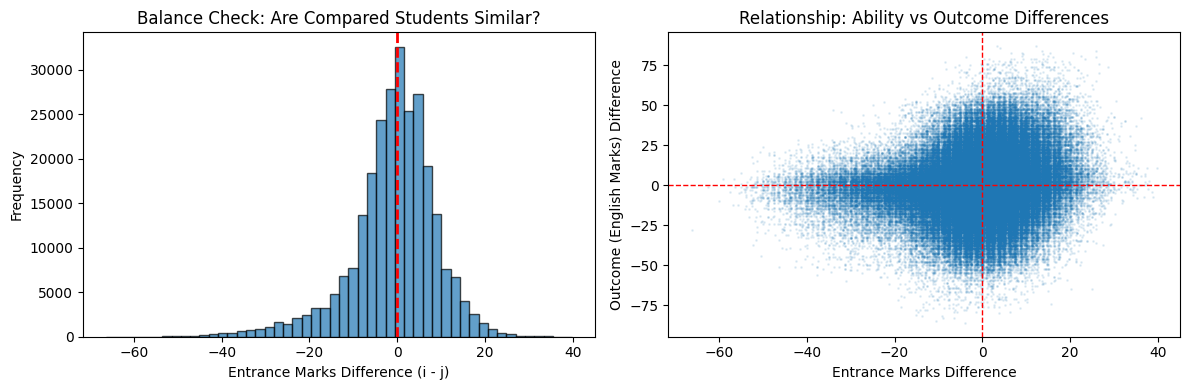

In [73]:
# ==========================================
# VALIDATION: Check Balance on Entrance Marks
# ==========================================

"""
CRITICAL VALIDITY CHECK:
Within our matched comparisons, students should have similar entrance marks.
If marks_diff is large, matching failed and estimates are biased.
"""

print("BALANCE CHECK: Are compared students similar in ability?")
print("="*60)

print("\nDistribution of entrance mark differences (marks_diff):")
print(comparison_df["marks_diff"].describe())

print("\n% of comparisons with |marks_diff| < 2.5:")
print(f"{(comparison_df['marks_diff'].abs() < 2.5).mean() * 100:.1f}%")

print("\n% of comparisons with |marks_diff| < 5:")
print(f"{(comparison_df['marks_diff'].abs() < 5).mean() * 100:.1f}%")

print("\nIf most comparisons have small marks_diff, matching is working well.")
print("If many comparisons have large marks_diff, increase similarity weights.")

# Plot if matplotlib available
try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(comparison_df["marks_diff"], bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_xlabel("Entrance Marks Difference (i - j)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Balance Check: Are Compared Students Similar?")
    
    axes[1].scatter(comparison_df["marks_diff"], comparison_df["outcome_diff"], 
                   alpha=0.1, s=1)
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
    axes[1].set_xlabel("Entrance Marks Difference")
    axes[1].set_ylabel("Outcome (English Marks) Difference")
    axes[1].set_title("Relationship: Ability vs Outcome Differences")
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("\n(Install matplotlib to see balance check plots)")

In [74]:
# ==========================================
# SAVE ATTEMPT 1 RESULTS
# ==========================================

import json
from datetime import datetime

# Create metadata dictionary
metadata = {
    "attempt": 1,
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "specification": {
        "weights": {
            "W_MARKS": 5.0,
            "W_PREFS": 2.0,
            "W_STREAM": 1.0,
            "W_DEMO": 0.5
        },
        "neighborhood_size": 50,
        "preference_decay": 0.8,
        "similarity_metric": "cosine",
        "outcome_variable": "englishmarks_12"
    },
    "sample": {
        "n_students": len(df_feat),
        "n_comparisons": len(comparison_df),
        "n_colleges": len(results_df)
    },
    "model_fit": {
        "r_squared": float(model.rsquared),
        "n_obs": int(model.nobs)
    },
    "balance_diagnostics": {
        "mean_marks_diff": float(comparison_df["marks_diff"].mean()),
        "std_marks_diff": float(comparison_df["marks_diff"].std()),
        "pct_within_2.5": float((comparison_df["marks_diff"].abs() < 2.5).mean() * 100),
        "pct_within_5.0": float((comparison_df["marks_diff"].abs() < 5.0).mean() * 100)
    },
    "value_added_summary": {
        "mean_abs_va": float(results_df["value_added"].abs().mean()),
        "min_va": float(results_df["value_added"].min()),
        "max_va": float(results_df["value_added"].max()),
        "n_sig_positive": int(((results_df['value_added'] > 0) & (results_df['p_value'] < 0.05)).sum()),
        "n_sig_negative": int(((results_df['value_added'] < 0) & (results_df['p_value'] < 0.05)).sum())
    }
}

# Add baseline college info
results_df['specification'] = 'attempt_1'
results_df['baseline_college'] = baseline_college

# Reorder columns for clarity
results_output = results_df[[
    'specification',
    'college_code',
    'value_added',
    'std_error',
    't_value',
    'p_value',
    'ci_lower',
    'ci_upper',
    'sig',
    'baseline_college'
]].copy()

# Save main results
results_output.to_csv('college_va_attempt1.csv', index=False)
print("✓ Saved: college_va_attempt1.csv")

# Save metadata as JSON
with open('college_va_attempt1_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Saved: college_va_attempt1_metadata.json")

# Save comparison dataset sample for diagnostics
comparison_sample = comparison_df.sample(min(10000, len(comparison_df)), random_state=42)
comparison_sample.to_csv('comparison_diagnostics_attempt1.csv', index=False)
print("✓ Saved: comparison_diagnostics_attempt1.csv (sample)")

# Create summary report
summary_report = f"""
================================================================================
COLLEGE VALUE-ADDED ESTIMATION - ATTEMPT 1 SUMMARY
================================================================================
Date: {metadata['date']}

SPECIFICATION:
--------------
  Weights:
    - Entrance Marks (ability): {metadata['specification']['weights']['W_MARKS']}
    - Preferences: {metadata['specification']['weights']['W_PREFS']}
    - Stream: {metadata['specification']['weights']['W_STREAM']}
    - Demographics: {metadata['specification']['weights']['W_DEMO']}
  
  Neighborhood Size: {metadata['specification']['neighborhood_size']}
  Preference Decay: {metadata['specification']['preference_decay']}
  Similarity Metric: {metadata['specification']['similarity_metric']}

SAMPLE:
-------
  Students: {metadata['sample']['n_students']:,}
  Comparisons: {metadata['sample']['n_comparisons']:,}
  Colleges: {metadata['sample']['n_colleges']}

MODEL FIT:
----------
  R-squared: {metadata['model_fit']['r_squared']:.4f}
  Observations: {metadata['model_fit']['n_obs']:,}

BALANCE DIAGNOSTICS:
--------------------
  Mean marks difference: {metadata['balance_diagnostics']['mean_marks_diff']:.2f}
  Std marks difference: {metadata['balance_diagnostics']['std_marks_diff']:.2f}
  % within ±2.5 marks: {metadata['balance_diagnostics']['pct_within_2.5']:.1f}%
  % within ±5.0 marks: {metadata['balance_diagnostics']['pct_within_5.0']:.1f}%
  
  ⚠ TARGET: 70%+ within ±2.5 marks for credible causal inference

VALUE-ADDED ESTIMATES:
----------------------
  Range: [{metadata['value_added_summary']['min_va']:.2f}, {metadata['value_added_summary']['max_va']:.2f}]
  Mean absolute VA: {metadata['value_added_summary']['mean_abs_va']:.2f}
  
  Significantly positive (p<0.05): {metadata['value_added_summary']['n_sig_positive']}
  Significantly negative (p<0.05): {metadata['value_added_summary']['n_sig_negative']}

INTERPRETATION:
---------------
  ⚠ Balance diagnostics suggest imperfect matching
  ⚠ Large negative estimates likely reflect selection bias
  ⚠ Estimates should be interpreted as upper bounds on true effects

RECOMMENDATION:
---------------
  Proceed to Attempt 2 with tighter matching specification

================================================================================
"""

with open('college_va_attempt1_summary.txt', 'w') as f:
    f.write(summary_report)
print("✓ Saved: college_va_attempt1_summary.txt")

print("\n" + summary_report)

✓ Saved: college_va_attempt1.csv
✓ Saved: college_va_attempt1_metadata.json
✓ Saved: comparison_diagnostics_attempt1.csv (sample)


UnicodeEncodeError: 'charmap' codec can't encode character '\u26a0' in position 801: character maps to <undefined>